In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("../Airlinedataset.csv")

df.head()

,days_to_departure,seats_remaining,historical_demand,competitor_price,booking_velocity,is_weekend,flight_capacity,occupied_seats,occupancy_rate,ticket_price
0,39,38,51,8030,30,1,150,112,0.746667,10783
1,52,96,30,8232,1,1,180,84,0.466667,8341
2,29,99,64,7250,11,0,180,81,0.450000,9062
3,15,76,52,6657,7,0,220,144,0.654545,9802
4,43,43,60,8183,17,1,150,107,0.713333,10643


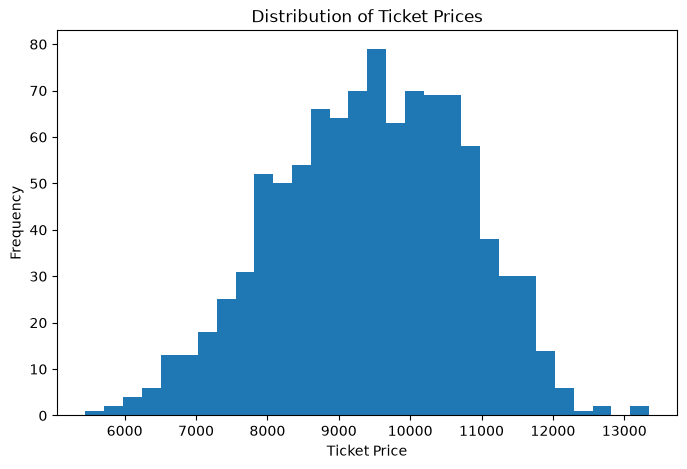

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(df["ticket_price"], bins=30)

plt.xlabel("Ticket Price")
plt.ylabel("Frequency")
plt.title("Distribution of Ticket Prices")

plt.show()

In [10]:
correlation = df.corr(numeric_only=True)

correlation["ticket_price"].sort_values(ascending=False)

ticket_price         1.000000
occupancy_rate       0.692376
occupied_seats       0.659943
historical_demand    0.316162
competitor_price     0.280460
booking_velocity     0.254947
is_weekend           0.151885
flight_capacity      0.139739
days_to_departure   -0.467352
seats_remaining     -0.672361
Name: ticket_price, dtype: float64

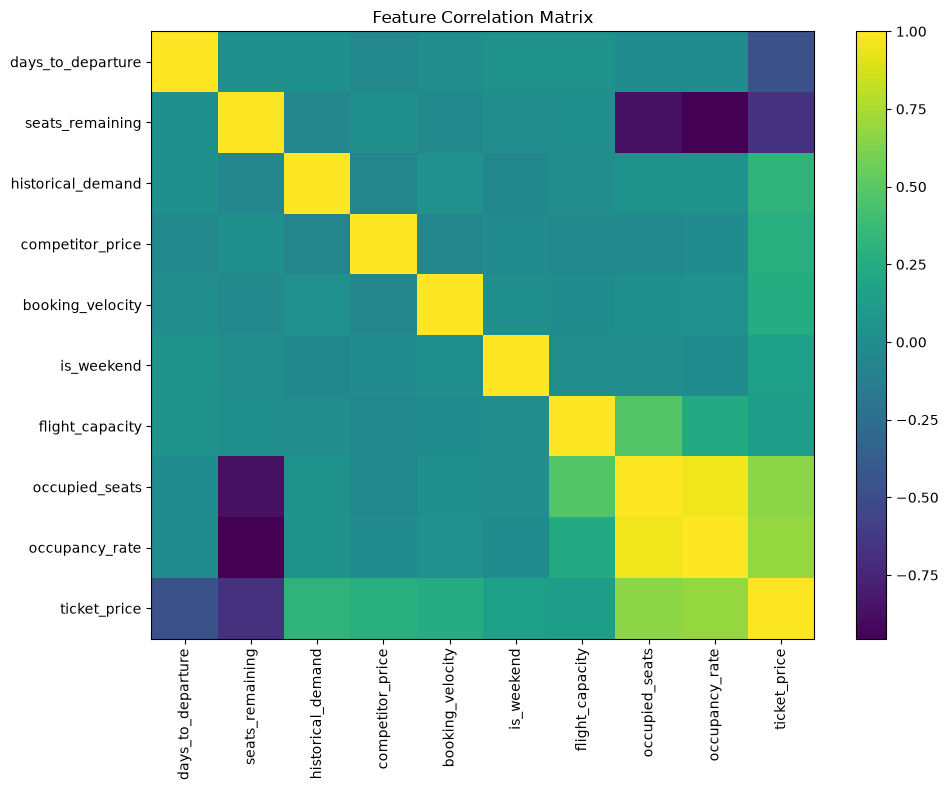

In [11]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

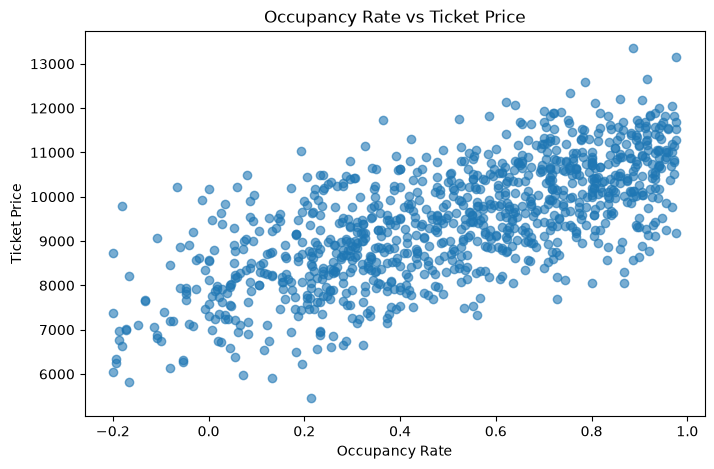

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["occupancy_rate"],
    df["ticket_price"],
    alpha=0.6
)

plt.xlabel("Occupancy Rate")
plt.ylabel("Ticket Price")
plt.title("Occupancy Rate vs Ticket Price")

plt.show()

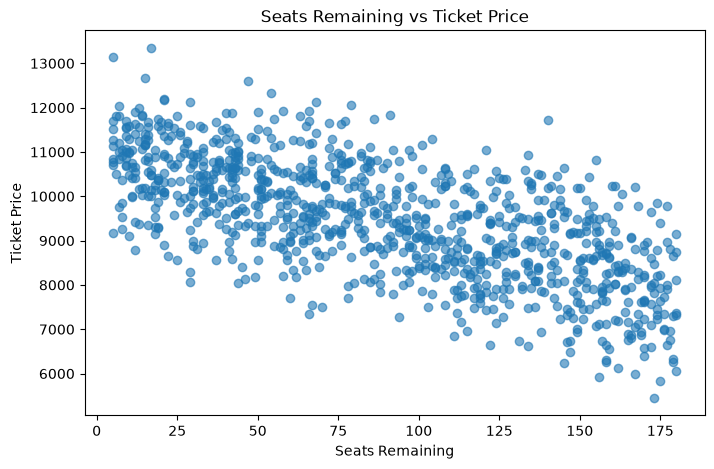

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["seats_remaining"],
    df["ticket_price"],
    alpha=0.6
)

plt.xlabel("Seats Remaining")
plt.ylabel("Ticket Price")
plt.title("Seats Remaining vs Ticket Price")

plt.show()

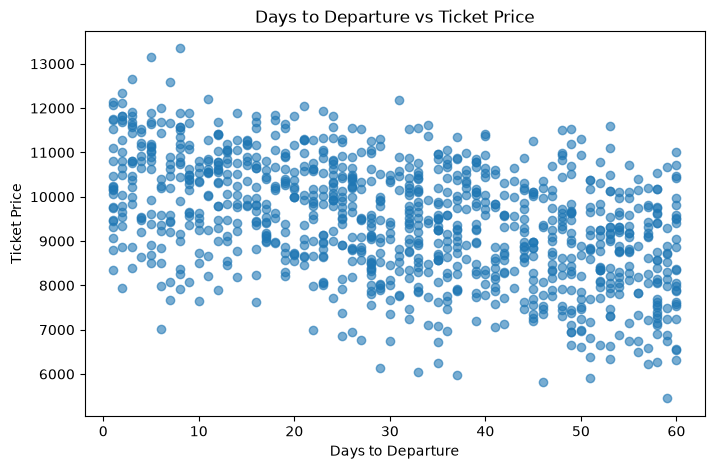

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["days_to_departure"],
    df["ticket_price"],
    alpha=0.6
)

plt.xlabel("Days to Departure")
plt.ylabel("Ticket Price")
plt.title("Days to Departure vs Ticket Price")

plt.show()

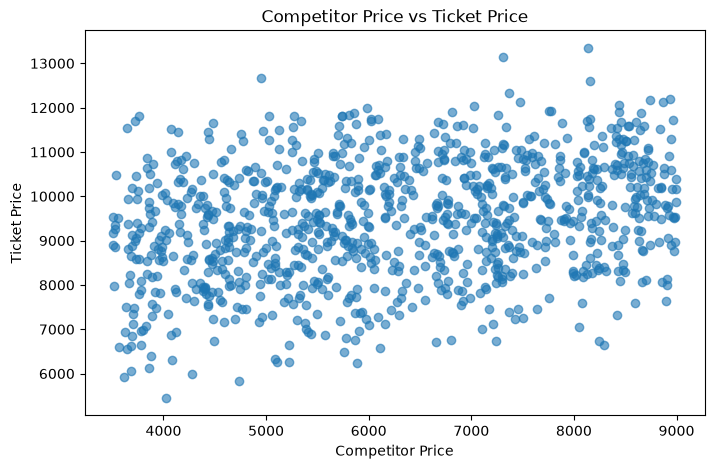

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["competitor_price"],
    df["ticket_price"],
    alpha=0.6
)

plt.xlabel("Competitor Price")
plt.ylabel("Ticket Price")
plt.title("Competitor Price vs Ticket Price")

plt.show()

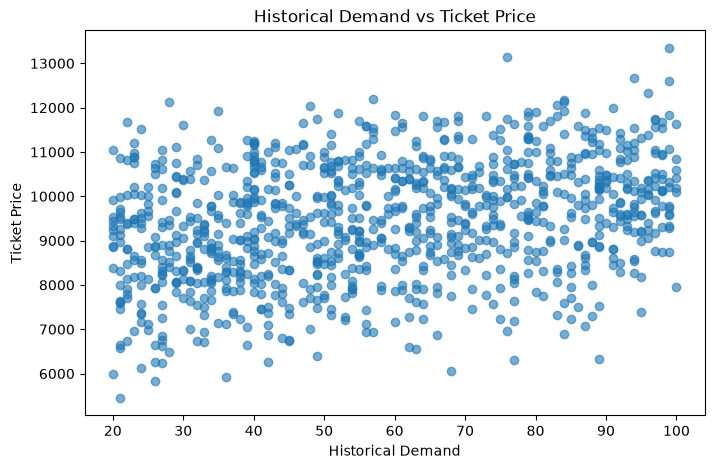

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["historical_demand"],
    df["ticket_price"],
    alpha=0.6
)

plt.xlabel("Historical Demand")
plt.ylabel("Ticket Price")
plt.title("Historical Demand vs Ticket Price")

plt.show()

In [17]:
df[
    [
        "occupancy_rate",
        "occupied_seats",
        "seats_remaining",
        "flight_capacity"
    ]
].corr()

,occupancy_rate,occupied_seats,seats_remaining,flight_capacity
occupancy_rate,1.000000,0.956400,-0.954427,0.237970
occupied_seats,0.956400,1.000000,-0.869048,0.477698
seats_remaining,-0.954427,-0.869048,1.000000,0.019488
flight_capacity,0.237970,0.477698,0.019488,1.000000


In [18]:
df["calculated_occupancy"] = (
    df["occupied_seats"] / df["flight_capacity"]
)

In [19]:
difference = (
    df["occupancy_rate"] - df["calculated_occupancy"]
).abs()

print("Maximum difference:", difference.max())
print("Mean difference:", difference.mean())

Maximum difference: 4.5454640051900697e-11
Mean difference: 2.1816111916116154e-11


In [20]:
df[
    [
        "flight_capacity",
        "occupied_seats",
        "seats_remaining",
        "occupancy_rate",
        "calculated_occupancy"
    ]
].head(10)

,flight_capacity,occupied_seats,seats_remaining,occupancy_rate,calculated_occupancy
0,150,112,38,0.746667,0.746667
1,180,84,96,0.466667,0.466667
2,180,81,99,0.450000,0.450000
3,220,144,76,0.654545,0.654545
4,150,107,43,0.713333,0.713333
5,180,22,158,0.122222,0.122222
6,180,14,166,0.077778,0.077778
7,180,58,122,0.322222,0.322222
8,220,213,7,0.968182,0.968182
9,180,53,127,0.294444,0.294444


In [21]:
df["calculated_seats_remaining"] = (
    df["flight_capacity"] - df["occupied_seats"]
)

In [22]:
difference_seats = (
    df["seats_remaining"] - df["calculated_seats_remaining"]
).abs()

print("Maximum difference:", difference_seats.max())
print("Mean difference:", difference_seats.mean())

Maximum difference: 0
Mean difference: 0.0


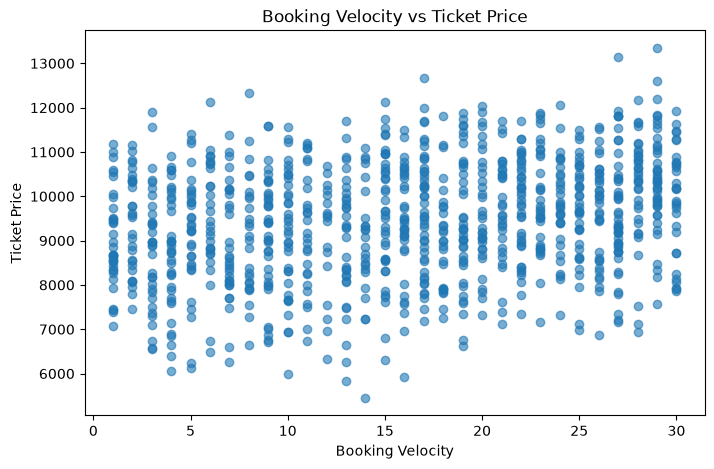

In [23]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["booking_velocity"],
    df["ticket_price"],
    alpha=0.6
)

plt.xlabel("Booking Velocity")
plt.ylabel("Ticket Price")
plt.title("Booking Velocity vs Ticket Price")

plt.show()

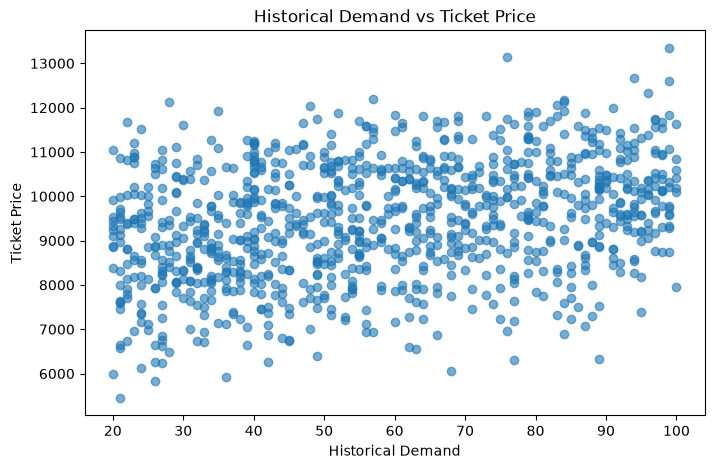

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["historical_demand"],
    df["ticket_price"],
    alpha=0.6
)

plt.xlabel("Historical Demand")
plt.ylabel("Ticket Price")
plt.title("Historical Demand vs Ticket Price")

plt.show()

In [25]:
df[
    [
        "days_to_departure",
        "seats_remaining",
        "historical_demand",
        "competitor_price",
        "booking_velocity",
        "ticket_price"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
days_to_departure,1000.0,31.200,17.372905,1.0,17.0,32.0,47.00,60.0
seats_remaining,1000.0,89.296,50.931625,5.0,44.0,87.0,134.00,180.0
historical_demand,1000.0,58.461,23.412232,20.0,39.0,57.0,79.00,100.0
competitor_price,1000.0,6264.393,1553.431407,3506.0,4977.0,6169.5,7508.25,8999.0
booking_velocity,1000.0,15.985,8.771757,1.0,8.0,17.0,24.00,30.0
ticket_price,1000.0,9454.540,1316.616664,5449.0,8535.0,9504.5,10450.75,13346.0


## EDA Findings

The exploratory analysis identified several relationships with ticket price.

- Ticket price has a strong positive relationship with occupancy rate and occupied seats.
- Ticket price has a strong negative relationship with seats remaining.
- Days to departure also shows a negative relationship with ticket price.
- Historical demand, competitor price, and booking velocity show moderate positive relationships with ticket price.
- Occupancy rate is mathematically derived from occupied seats and flight capacity.
- Seats remaining is derived from flight capacity and occupied seats.

Because several seat-related variables contain overlapping information, the initial ML model will use a controlled feature set rather than automatically including every available column.